In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder 
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBRFClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df=pd.read_csv("telco_churn.csv")

In [3]:
df.shape

(5043, 22)

In [4]:
df.isnull().sum()

Unnamed: 0            0
customerID            0
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines       269
InternetService       0
OnlineSecurity      651
OnlineBackup        651
DeviceProtection    651
TechSupport         651
StreamingTV         651
StreamingMovies     651
Contract              0
PaperlessBilling      0
PaymentMethod         0
MonthlyCharges        0
TotalCharges          5
Churn                 1
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        5043 non-null   int64  
 1   customerID        5043 non-null   object 
 2   gender            5043 non-null   object 
 3   SeniorCitizen     5043 non-null   object 
 4   Partner           5043 non-null   object 
 5   Dependents        5043 non-null   object 
 6   tenure            5043 non-null   int64  
 7   PhoneService      5043 non-null   object 
 8   MultipleLines     4774 non-null   object 
 9   InternetService   5043 non-null   object 
 10  OnlineSecurity    4392 non-null   object 
 11  OnlineBackup      4392 non-null   object 
 12  DeviceProtection  4392 non-null   object 
 13  TechSupport       4392 non-null   object 
 14  StreamingTV       4392 non-null   object 
 15  StreamingMovies   4392 non-null   object 
 16  Contract          5043 non-null   object 


In [6]:
df['MultipleLines']=df['MultipleLines'].fillna(df['MultipleLines'].mode()[0])

In [7]:
df['OnlineSecurity']=df['OnlineSecurity'].fillna(df['OnlineSecurity'].mode()[0])

In [8]:
df['OnlineBackup']= df['OnlineBackup'].fillna(df['OnlineBackup'].mode()[0])

In [9]:
df['DeviceProtection']=df['DeviceProtection'].fillna(df['DeviceProtection'].mode()[0])

In [10]:
df['TechSupport']=df['TechSupport'].fillna(df['TechSupport'].mode()[0])

In [11]:
df['StreamingTV']=df['StreamingTV'].fillna(df['StreamingTV'].mode()[0])

In [12]:
df['StreamingMovies']=df['StreamingMovies'].fillna(df['StreamingMovies'].mode()[0])

In [13]:
df['Churn']=df['Churn'].fillna(df['Churn'].mode()[0])

In [14]:
df['TotalCharges']=df['TotalCharges'].fillna(df['TotalCharges'].mode()[0])

In [15]:
df.isnull().sum()

Unnamed: 0          0
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [16]:
df=df.drop(columns=['customerID'])

In [17]:
df.head(1)

,Unnamed: 0,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Female,False,True,False,1,False,False,DSL,False,...,False,False,False,False,Month-to-month,True,Electronic check,29.85,29.850000381469727,False


In [18]:
for col in df.columns:
    print(col,df[col].unique)
    print("_"*50)

Unnamed: 0 <bound method Series.unique of 0          0
1          1
2          2
3          3
4          4
        ... 
5038    2038
5039    2039
5040    2040
5041    2041
5042    2042
Name: Unnamed: 0, Length: 5043, dtype: int64>
__________________________________________________
gender <bound method Series.unique of 0       Female
1         Male
2         Male
3         Male
4       Female
         ...  
5038      Male
5039    Female
5040    Female
5041      Male
5042      Male
Name: gender, Length: 5043, dtype: object>
__________________________________________________
SeniorCitizen <bound method Series.unique of 0       False
1       False
2       False
3       False
4       False
        ...  
5038        0
5039        0
5040        0
5041        1
5042        0
Name: SeniorCitizen, Length: 5043, dtype: object>
__________________________________________________
Partner <bound method Series.unique of 0        True
1       False
2       False
3       False
4       False
        ... 

In [19]:
numerical_features_list=['tenure', 'MonthlyCharges', 'TotalCharges']
for col in df.columns:
    if col not in numerical_features_list:
        print(col,df[col].unique)
        print("_"*50)

Unnamed: 0 <bound method Series.unique of 0          0
1          1
2          2
3          3
4          4
        ... 
5038    2038
5039    2039
5040    2040
5041    2041
5042    2042
Name: Unnamed: 0, Length: 5043, dtype: int64>
__________________________________________________
gender <bound method Series.unique of 0       Female
1         Male
2         Male
3         Male
4       Female
         ...  
5038      Male
5039    Female
5040    Female
5041      Male
5042      Male
Name: gender, Length: 5043, dtype: object>
__________________________________________________
SeniorCitizen <bound method Series.unique of 0       False
1       False
2       False
3       False
4       False
        ...  
5038        0
5039        0
5040        0
5041        1
5042        0
Name: SeniorCitizen, Length: 5043, dtype: object>
__________________________________________________
Partner <bound method Series.unique of 0        True
1       False
2       False
3       False
4       False
        ... 

In [20]:
df[df["TotalCharges"]==" "]

,Unnamed: 0,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3218,218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
4670,1670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No
4754,1754,Male,0,No,Yes,0,Yes,Yes,DSL,Yes,...,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,,No


In [21]:
len(df[df["TotalCharges"]==" "])

3

In [22]:
df["TotalCharges"]= df["TotalCharges"].replace({" ":"0.0"})

In [23]:
df["TotalCharges"]=df["TotalCharges"].astype(float)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        5043 non-null   int64  
 1   gender            5043 non-null   object 
 2   SeniorCitizen     5043 non-null   object 
 3   Partner           5043 non-null   object 
 4   Dependents        5043 non-null   object 
 5   tenure            5043 non-null   int64  
 6   PhoneService      5043 non-null   object 
 7   MultipleLines     5043 non-null   object 
 8   InternetService   5043 non-null   object 
 9   OnlineSecurity    5043 non-null   object 
 10  OnlineBackup      5043 non-null   object 
 11  DeviceProtection  5043 non-null   object 
 12  TechSupport       5043 non-null   object 
 13  StreamingTV       5043 non-null   object 
 14  StreamingMovies   5043 non-null   object 
 15  Contract          5043 non-null   object 
 16  PaperlessBilling  5043 non-null   object 


In [25]:
print(df["Churn"].value_counts())

Churn
False    2220
No       1487
True      780
Yes       556
Name: count, dtype: int64


In [26]:
df.describe()

,Unnamed: 0,tenure,MonthlyCharges,TotalCharges
count,5043.000000,5043.000000,5043.000000,5043.000000
mean,1305.651993,32.576641,65.090214,2298.430548
std,801.484415,24.529807,30.068133,2269.512951
min,0.000000,0.000000,18.400000,0.000000
25%,630.000000,9.000000,35.775000,415.724997
50%,1260.000000,29.000000,70.550003,1398.599976
75%,1890.500000,56.000000,90.050003,3857.575073
max,2999.000000,72.000000,118.650002,8670.100000


In [27]:
def plot_histogram(df, column_name):
    plt.figure(figsize=(5,3))
    sns.histplot(df[column_name], kde=True)
    plt.title(f"Distribution of {column_name}")
    col_mean= df[column_name].mean()
    col_median=df[column_name].median()
    plt.axvline(col_mean, color="red", linestyle="--", label="mean")
    plt.axvline(col_median, color="green", linestyle="--", label="median")

    plt.legend()
    plt.show()

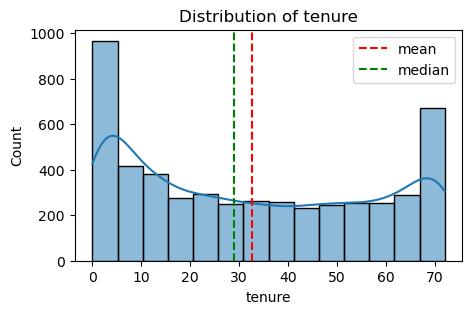

In [28]:
plot_histogram(df, "tenure")

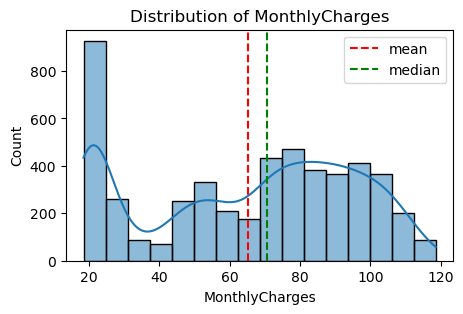

In [29]:
plot_histogram(df, "MonthlyCharges")

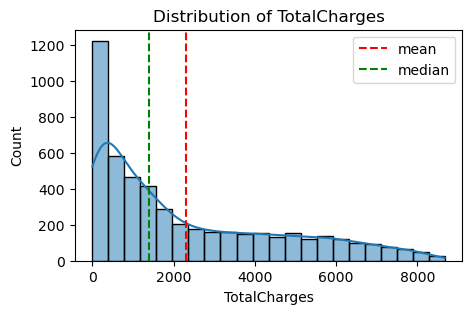

In [30]:
plot_histogram(df, "TotalCharges")

In [31]:
def plot_boxplot(df, column_name):
    plt.figure(figsize=(5,4))
    sns.boxplot(y=df[column_name])
    plt.title(f"Distribution of {column_name}")
    plt.ylabel(column_name)
    plt.show()

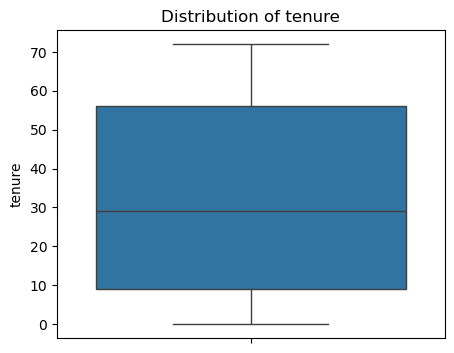

In [32]:
plot_boxplot(df, "tenure")

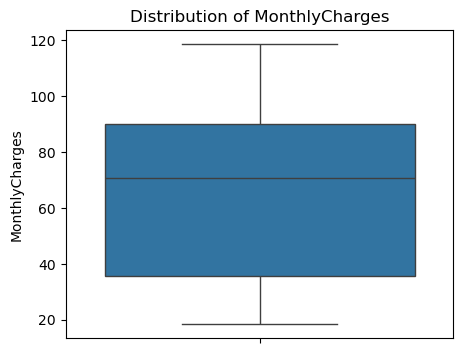

In [33]:
plot_boxplot(df, "MonthlyCharges")

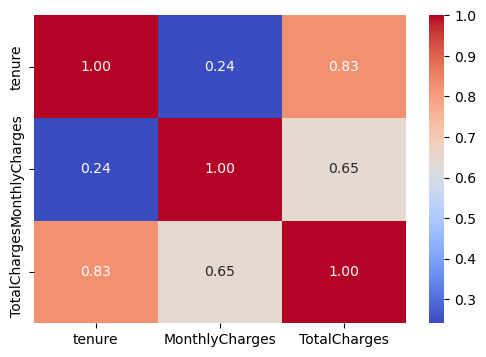

In [34]:
plt.figure(figsize=(6,4))
sns.heatmap(df[["tenure", "MonthlyCharges", "TotalCharges"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title=("Correlation Heatmap")
plt.show()

In [35]:
object_cols= df.select_dtypes(include="object").columns.to_list()
object_cols

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [36]:
object_cols= ["SeniorCitizen"] + object_cols
print(object_cols)

['SeniorCitizen', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


TypeError: 'str' object is not callable

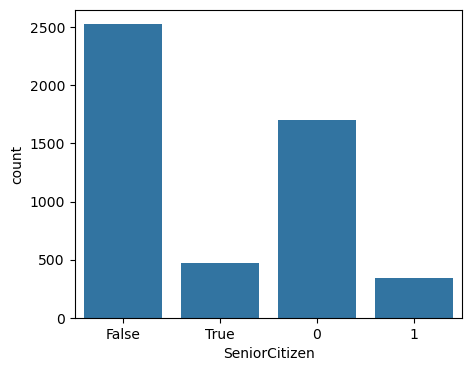

In [37]:
object_cols= ["SeniorCitizen"] + object_cols
for col in object_cols:
    plt.figure(figsize=(5,4))
    sns.countplot(x=df[col])
    plt.title(f"Count Plot of {col}")
    plt.show()

In [ ]:
sns.countplot(x=df["gender"])

<Axes: xlabel='Churn', ylabel='count'>

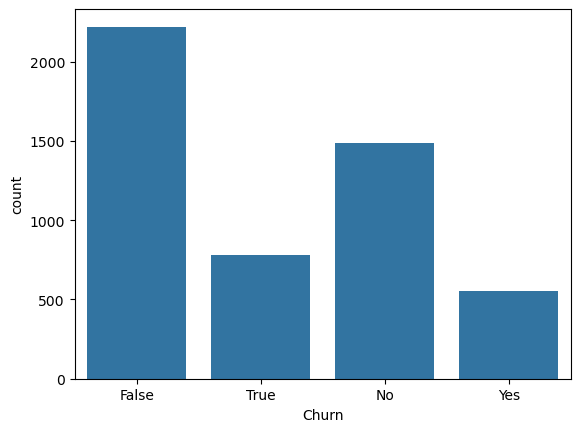

In [38]:
sns.countplot(x=df["Churn"])

In [39]:
df.columns

Index(['Unnamed: 0', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

<Axes: xlabel='PaymentMethod', ylabel='count'>

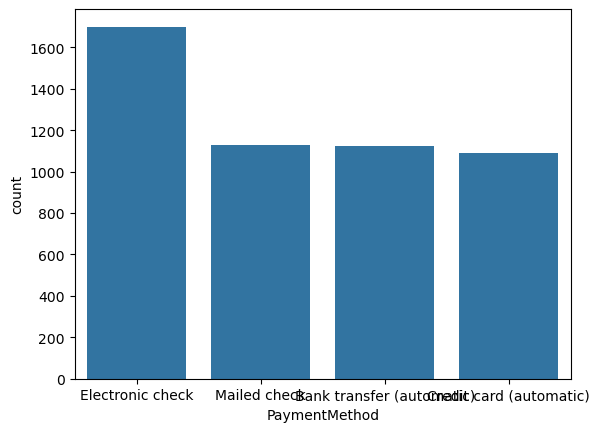

In [40]:
sns.countplot(x=df["PaymentMethod"])

In [41]:
df["Churn"]= df["Churn"].replace({"Yes": 1, "No": 0})

In [42]:
object_columns=df.select_dtypes(include="object").columns

In [43]:
print(object_columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')


In [44]:
import pickle

In [45]:
encoders = {} 

for column in object_columns:
    le=LabelEncoder()
    df[column] = df[column].astype(str)
    df[column] = le.fit_transform(df[column])
    encoders[column]=le

with open("encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

In [46]:
 encoders

{'gender': LabelEncoder(),
 'SeniorCitizen': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder(),
 'Churn': LabelEncoder()}

In [47]:
df.head(2)

,Unnamed: 0,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,2,2,0,1,0,0,0,0,...,0,0,0,0,0,2,2,29.850000,29.85,2
1,1,1,2,0,0,34,2,0,0,3,...,3,0,0,0,1,0,3,56.950001,1889.50,2


In [48]:
x= df.drop(columns=["Churn"])
y=df["Churn"]

In [49]:
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.2, random_state=41)

In [50]:
print(x_train.shape)

(4034, 20)


In [51]:
print(y_train.shape)

(4034,)


In [52]:
print(y_train.value_counts())

Churn
2    1783
0    1194
3     619
1     438
Name: count, dtype: int64


In [53]:
smote= SMOTE(random_state=41)

In [54]:
x_train_smote, y_train_smote=smote.fit_resample(x_train, y_train)

In [55]:
print(y_train_smote.shape)

(7132,)


In [56]:
print(y_train_smote.value_counts())

Churn
0    1783
2    1783
3    1783
1    1783
Name: count, dtype: int64


In [57]:
from xgboost import XGBClassifier

In [58]:
models= {
    "Decision Tree": DecisionTreeClassifier(random_state=41),
    "Random Forest": RandomForestClassifier(random_state=41),
    "XGBoost": XGBClassifier(random_state=41)
}

In [59]:
cv_scores={}
for model_name, model in models.items():
    print(model_name)
    print(model)
    print("_"*50)

Decision Tree
DecisionTreeClassifier(random_state=41)
__________________________________________________
Random Forest
RandomForestClassifier(random_state=41)
__________________________________________________
XGBoost
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)
_____________________

In [60]:
from sklearn.model_selection import train_test_split, cross_val_score

In [61]:
for model__name, model in models.items():
    print(f"Training {model_name} with default parameters")
    scores= cross_val_score(model, x_train_smote, y_train_smote, cv=5, scoring="accuracy")
    cv_scores[model_name]= scores
    print(f"{model_name} cross_validation accuracy: {np.mean(scores):.2f}")

Training XGBoost with default parameters
XGBoost cross_validation accuracy: 0.80
Training XGBoost with default parameters
XGBoost cross_validation accuracy: 0.87
Training XGBoost with default parameters
XGBoost cross_validation accuracy: 0.87


In [62]:
cv_scores

{'XGBoost': array([0.74001402, 0.85003504, 0.91725105, 0.90673212, 0.914446  ])}

In [63]:
rfc= RandomForestClassifier()

In [64]:
model.fit(x_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [65]:
print(y_test.value_counts())

Churn
2    437
0    293
3    161
1    118
Name: count, dtype: int64


In [66]:
y_test_pred= model.predict(x_test)

print("Accuracy Score:\n", accuracy_score(y_test, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))

Accuracy Score:
 0.77601585728444
Confusion Matrix:
 [[261  32   0   0]
 [ 55  63   0   0]
 [  0   0 374  63]
 [  0   0  76  85]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86       293
           1       0.66      0.53      0.59       118
           2       0.83      0.86      0.84       437
           3       0.57      0.53      0.55       161

    accuracy                           0.78      1009
   macro avg       0.72      0.70      0.71      1009
weighted avg       0.77      0.78      0.77      1009



In [67]:
with open("customer_churn_model.pkl", "wb") as f:
          pickle.dump(rfc, f)

In [68]:
model_data= {"model": rfc, "features_names": x.columns.tolist()}

with open("customer_churn_model.pkl", "wb") as f:
          pickle.dump(rfc, f)

In [69]:
print(x.columns.tolist())

['Unnamed: 0', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [70]:
with open("customer_churn_model.pkl", "wb") as f:
          pickle.dump(rfc, f)

loaded_model= model_data["model"]
features_names= model_data["features_names"]

In [71]:
print(loaded_model)

RandomForestClassifier()


In [72]:
print(features_names)

['Unnamed: 0', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [79]:
input_data= {
 'gender': 'Female',
 'SeniorCitizen': '0',
 'Partner': 'Yes',
 'Dependents': 'No',
 'tenure': 1,
 'PhoneService': 'No',
 'MultipleLines': 'No phone service',
 'InternetService': 'DSL',
 'OnlineSecurity': 'No',
 'OnlineBackup': 'Yes',
 'DeviceProtection': 'No',
 'TechSupport': 'No',
 'StreamingTV': 'No',
 'StreamingMovies': 'No',
 'Contract': 'Month-to-month',
 'PaperlessBilling': 'Yes',
 'PaymentMethod': 'Electronic check',
 'MonthlyCharges': 29.85,
 'TotalCharges': 29.85,
 'Churn': '1'
}

In [80]:
input_df= pd.DataFrame([input_data])
with open("encoders.pkl", "rb") as f:
    encoders= pickle.load(f)

print(input_df.head())

for column, encoder in encoders.items():
    input_df[column]= encoder.transform(input_df[column])

prediction= loaded_model.predict(input_df)
pred_prob= loaded_model.predict_proba(input_df)

print(prediction)

print(f"Prediction: {'Churn' if prediction[0] == 1 else 'No Churn'}")
print(f"Prediction Probablity: {pred_prob}")

   gender SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female             0     Yes         No       1           No   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   

  PaperlessBilling     PaymentMethod  MonthlyCharges  TotalCharges Churn  
0              Yes  Electronic check           29.85         29.85     1  


NotFittedError: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.